In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sc.settings.verbosity = 3
sc.settings.figdir = '../figures/'
sc.settings.set_figure_params(dpi=150, facecolor='white')

print("scanpy version:", sc.__version__)
print("All imports successful!")

scanpy version: 1.11.5
All imports successful!


C:\Users\Dell\AppData\Local\Temp\ipykernel_16760\2831137769.py:10: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy version:", sc.__version__)


In [2]:
import os

# Create figures directory if it doesn't exist
os.makedirs('../figures', exist_ok=True)

# Load the data
df = pd.read_csv(
    '../data/GSM4923494_HUB-JB-g001.tsv.gz',
    sep='\t',
    index_col=0,
    compression='gzip'
)

print("Shape of raw matrix:", df.shape)
print("First 5 gene names:", df.index[:5].tolist())
print("First 5 cell barcodes:", df.columns[:5].tolist())



Shape of raw matrix: (23397, 5015)
First 5 gene names: ['FAM138A', 'OR4F5', 'LOC100996442', 'OR4F16', 'OR4F16.1']
First 5 cell barcodes: ['HUB-JB-g001_1', 'HUB-JB-g001_2', 'HUB-JB-g001_3', 'HUB-JB-g001_4', 'HUB-JB-g001_5']


In [3]:
# This will take about 30–60 seconds to load. 
# That tells us if the matrix is oriented correctly before we flip it into AnnData.

# Transpose: scanpy needs rows=cells, columns=genes
adata = sc.AnnData(df.T)

print(f"AnnData object: {adata.n_obs} cells × {adata.n_vars} genes")

# Flag mitochondrial genes (start with MT-)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
print(f"Mitochondrial genes found: {adata.var['mt'].sum()}")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
)

print("\nQC metrics calculated successfully!")
print("Columns added to adata.obs:")
print(adata.obs.columns.tolist())



AnnData object: 5015 cells × 23397 genes
Mitochondrial genes found: 0

QC metrics calculated successfully!
Columns added to adata.obs:
['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


In [4]:
# Good progress! The 0 mitochondrial genes is something we need to fix 
# it means the MT genes in this dataset use a different naming format

In [5]:
# this tells us the exact naming so we flag them correctly before plotting QC.

# Check how mitochondrial genes are named in this dataset
mt_check = [g for g in adata.var_names if 'MT' in g.upper()]
print("MT-related genes found:", mt_check[:20])

# Also check a few specific ones
for gene in ['MT-CO1', 'MT-ND1', 'MTCO1', 'mt-Co1']:
    print(f"{gene} in dataset: {gene in adata.var_names}")

MT-related genes found: ['ICMT', 'CAMTA1', 'MTOR', 'MTOR.AS1', 'MTHFR', 'MTFR1L', 'MTF1', 'MTF2', 'TRMT13', 'PRMT6', 'HENMT1', 'LAMTOR5', 'MTMR11', 'ADAMTSL4', 'MTX1', 'LAMTOR2', 'ADAMTS4', 'EEF1AKNMT', 'TRMT1L', 'MTR']
MT-CO1 in dataset: False
MT-ND1 in dataset: False
MTCO1 in dataset: False
mt-Co1 in dataset: False


In [6]:
# Interesting! The mitochondrial genes are simply absent from this dataset 
# this is actually normal for some processed scRNA-seq matrices where MT genes were removed during upstream processing. 
# This is fine and actually common.
# We'll skip the MT filter and just use gene count filters

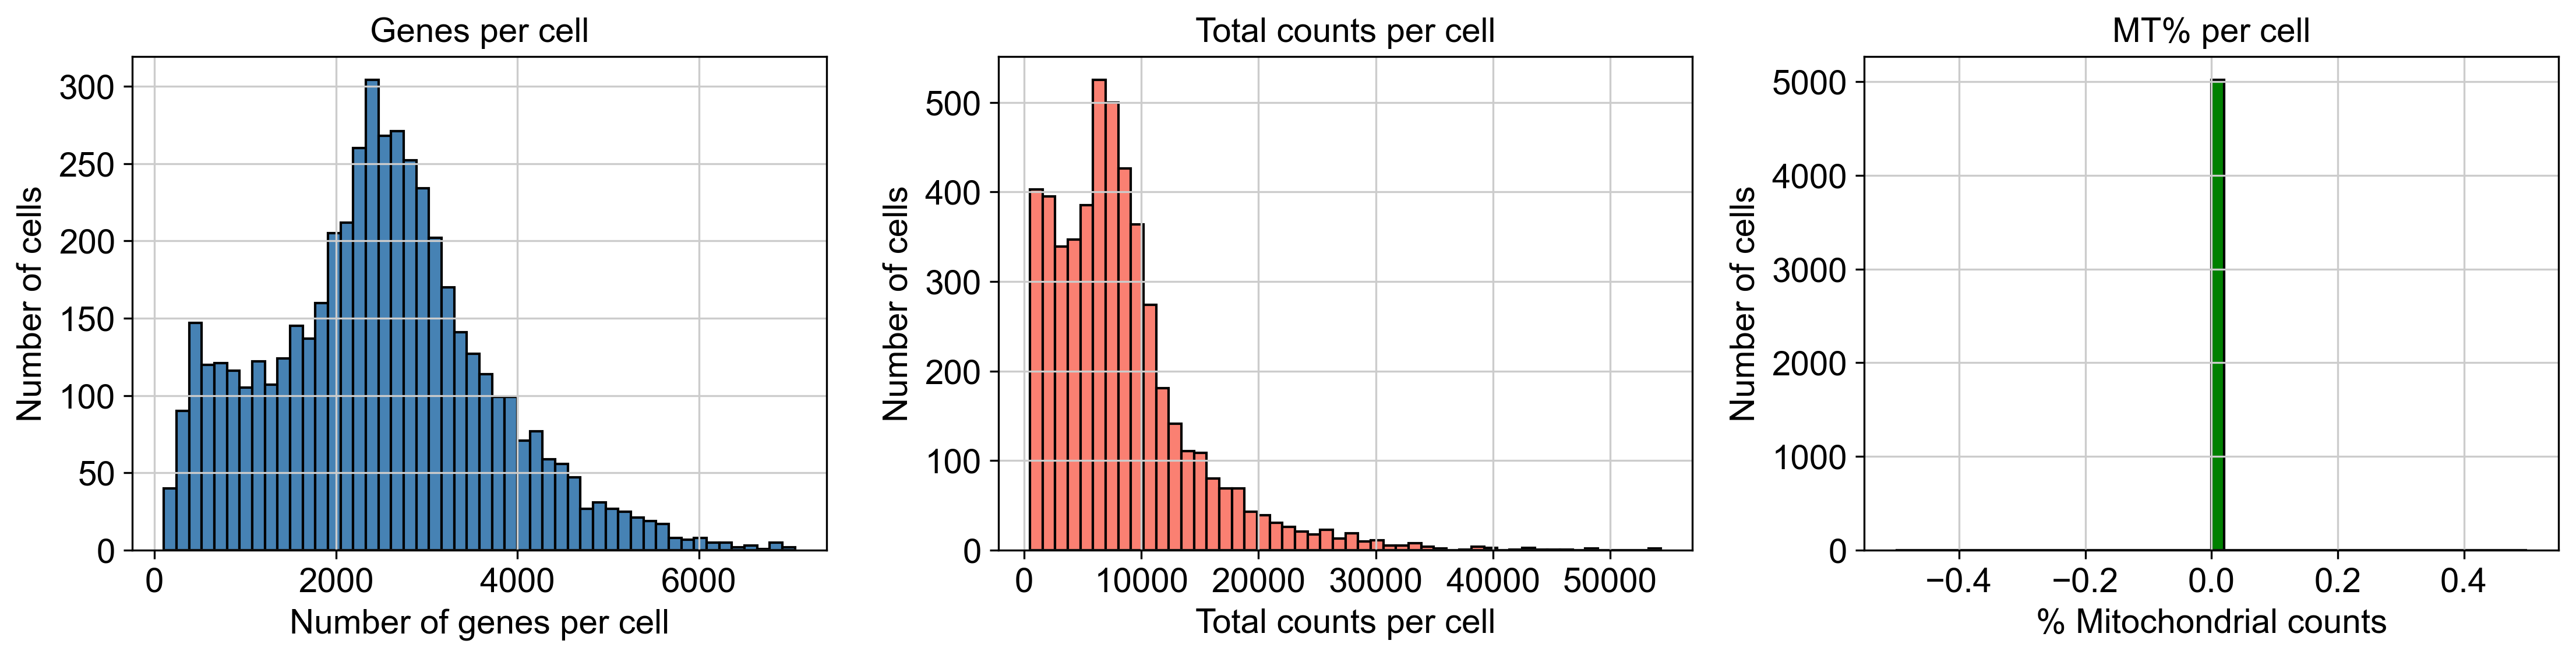


Genes per cell — min: 105, max: 7057, median: 2464
Total counts — min: 500, max: 54332, median: 7205


In [7]:
# Plot QC metrics to decide filter thresholds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(adata.obs['n_genes_by_counts'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of genes per cell')
axes[0].set_ylabel('Number of cells')
axes[0].set_title('Genes per cell')

axes[1].hist(adata.obs['total_counts'], bins=50, color='salmon', edgecolor='black')
axes[1].set_xlabel('Total counts per cell')
axes[1].set_ylabel('Number of cells')
axes[1].set_title('Total counts per cell')

axes[2].hist(adata.obs['pct_counts_mt'], bins=50, color='green', edgecolor='black')
axes[2].set_xlabel('% Mitochondrial counts')
axes[2].set_ylabel('Number of cells')
axes[2].set_title('MT% per cell')

plt.tight_layout()
plt.savefig('../figures/qc_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGenes per cell — min: {adata.obs['n_genes_by_counts'].min():.0f}, "
      f"max: {adata.obs['n_genes_by_counts'].max():.0f}, "
      f"median: {adata.obs['n_genes_by_counts'].median():.0f}")
print(f"Total counts — min: {adata.obs['total_counts'].min():.0f}, "
      f"max: {adata.obs['total_counts'].max():.0f}, "
      f"median: {adata.obs['total_counts'].median():.0f}")



In [8]:
# Good numbers! The data looks clean already 
# median of 2,464 genes per cell is healthy.

In [9]:
print(f"Cells before filtering: {adata.n_obs}")

# Filter cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, max_genes=6000)
sc.pp.filter_genes(adata, min_cells=3)

print(f"Cells after filtering: {adata.n_obs}")
print(f"Genes after filtering: {adata.n_vars}")

# Save raw counts before normalisation
adata.raw = adata.copy()

# Normalise to 10,000 counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Log transform
sc.pp.log1p(adata)

print("\nNormalisation complete!")
print(f"Final object: {adata.n_obs} cells × {adata.n_vars} genes")

# Save checkpoint
adata.write('../data/adata_qc.h5ad')
print("Saved to data/adata_qc.h5ad")

# applying filters and normalising in this code block

Cells before filtering: 5015
filtered out 26 cells that have less than 200 genes expressed
filtered out 26 cells that have more than 6000 genes expressed
filtered out 7584 genes that are detected in less than 3 cells
Cells after filtering: 4963
Genes after filtering: 15813
normalizing counts per cell
    finished (0:00:00)

Normalisation complete!
Final object: 4963 cells × 15813 genes
Saved to data/adata_qc.h5ad


In [10]:
# Lost only 52 cells (5015 → 4963) — very clean dataset
# 15,813 genes remaining — healthy number
# This matches what a well-processed dataset looks like

In [11]:
# Day 2 - CLustering

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes: 2574


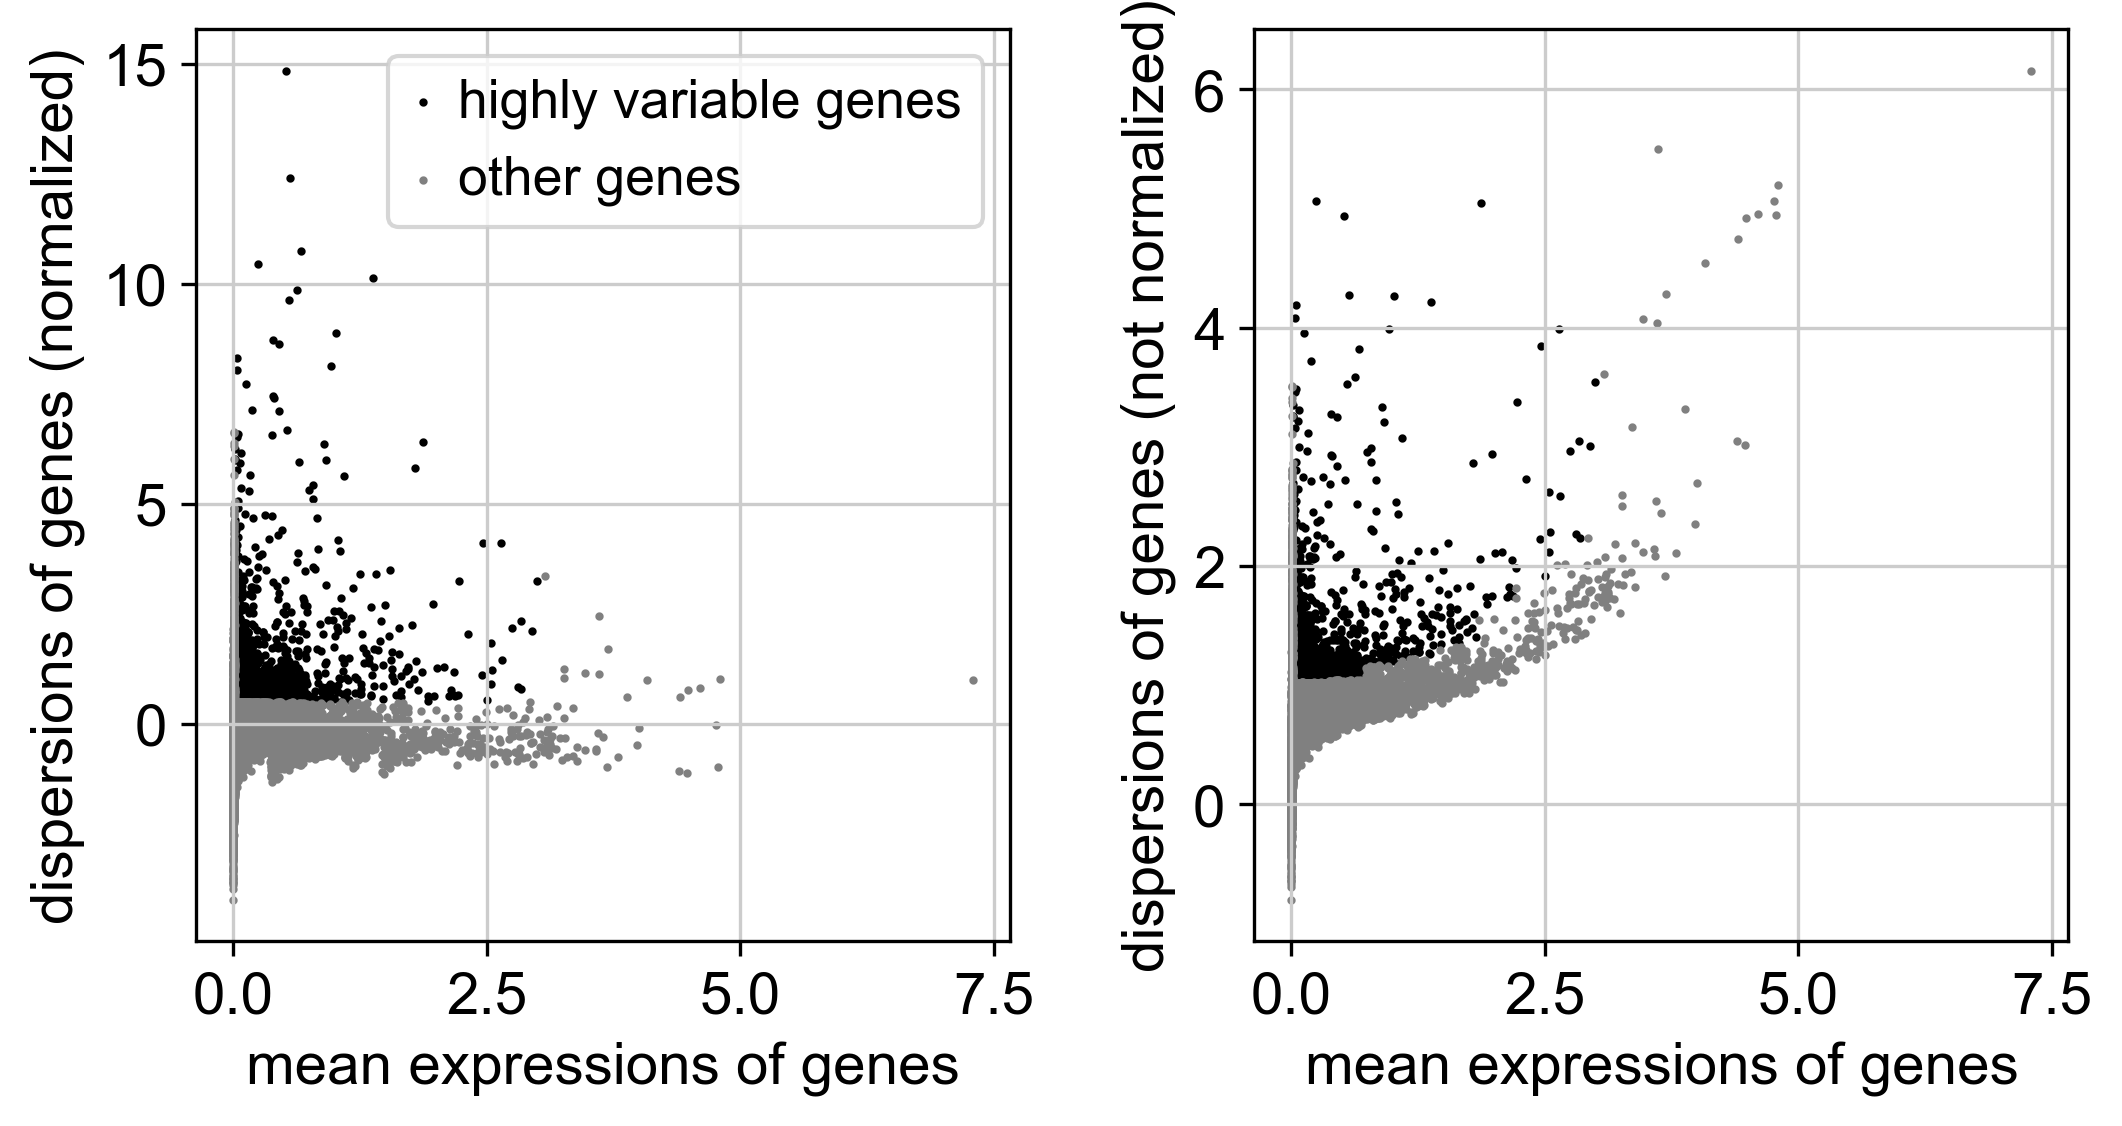

Object after HVG selection: 4963 cells × 2574 genes
Scaling done!


In [12]:
# Find highly variable genes
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

print(f"Highly variable genes: {adata.var['highly_variable'].sum()}")

# Plot HVGs
sc.pl.highly_variable_genes(adata, save='_hvg.png')

# Keep only HVGs for analysis
adata = adata[:, adata.var.highly_variable].copy()
print(f"Object after HVG selection: {adata.n_obs} cells × {adata.n_vars} genes")

# Scale genes
sc.pp.scale(adata, max_value=10)
print("Scaling Complete")

In [13]:
# Perfect! 2,574 highly variable genes 
# that's a great number for clustering

computing PCA
    with n_comps=50
    finished (0:00:02)


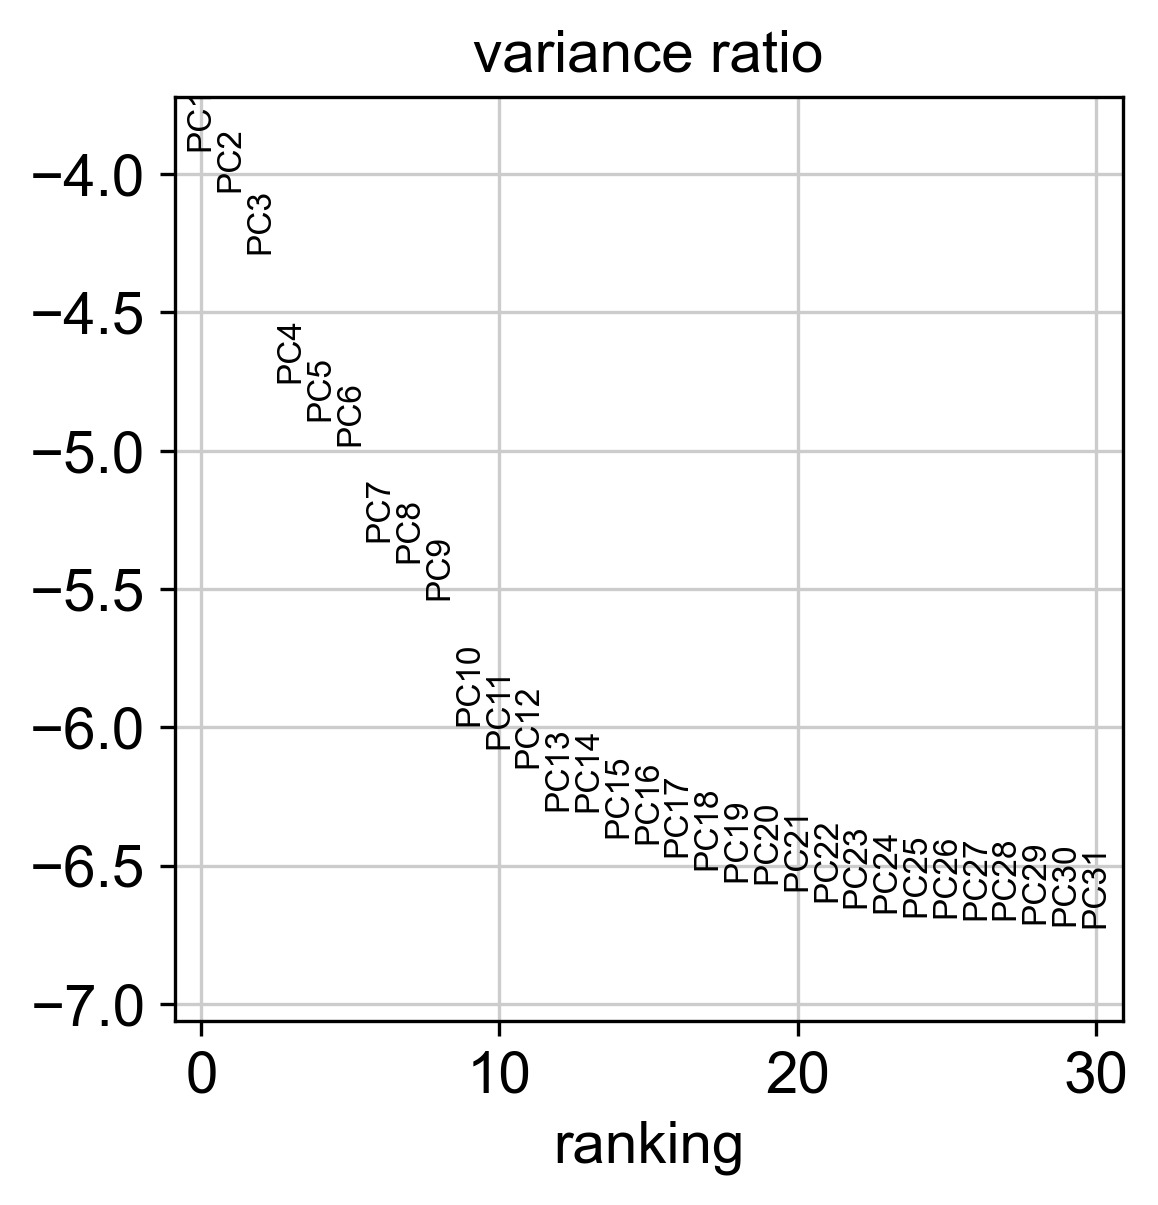

PCA Complete
PCA shape: (4963, 50)


In [14]:
# Run PCA
sc.tl.pca(adata, svd_solver='arpack')

# Plot variance explained by each PC
sc.pl.pca_variance_ratio(adata, n_pcs=30, log=True, save='_pca_variance.png')

print("PCA Complete")
print(f"PCA shape: {adata.obsm['X_pca'].shape}")

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:45)
Neighbour graph built
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:09)
UMAP Complete
running Leiden clustering


C:\Users\Dell\AppData\Local\Temp\ipykernel_16760\2376976801.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
Leiden clustering complete
Number of clusters found: 9
Cluster sizes:
leiden
0    1072
1     884
2     860
3     775
4     520
5     325
6     260
7     223
8      44
Name: count, dtype: int64


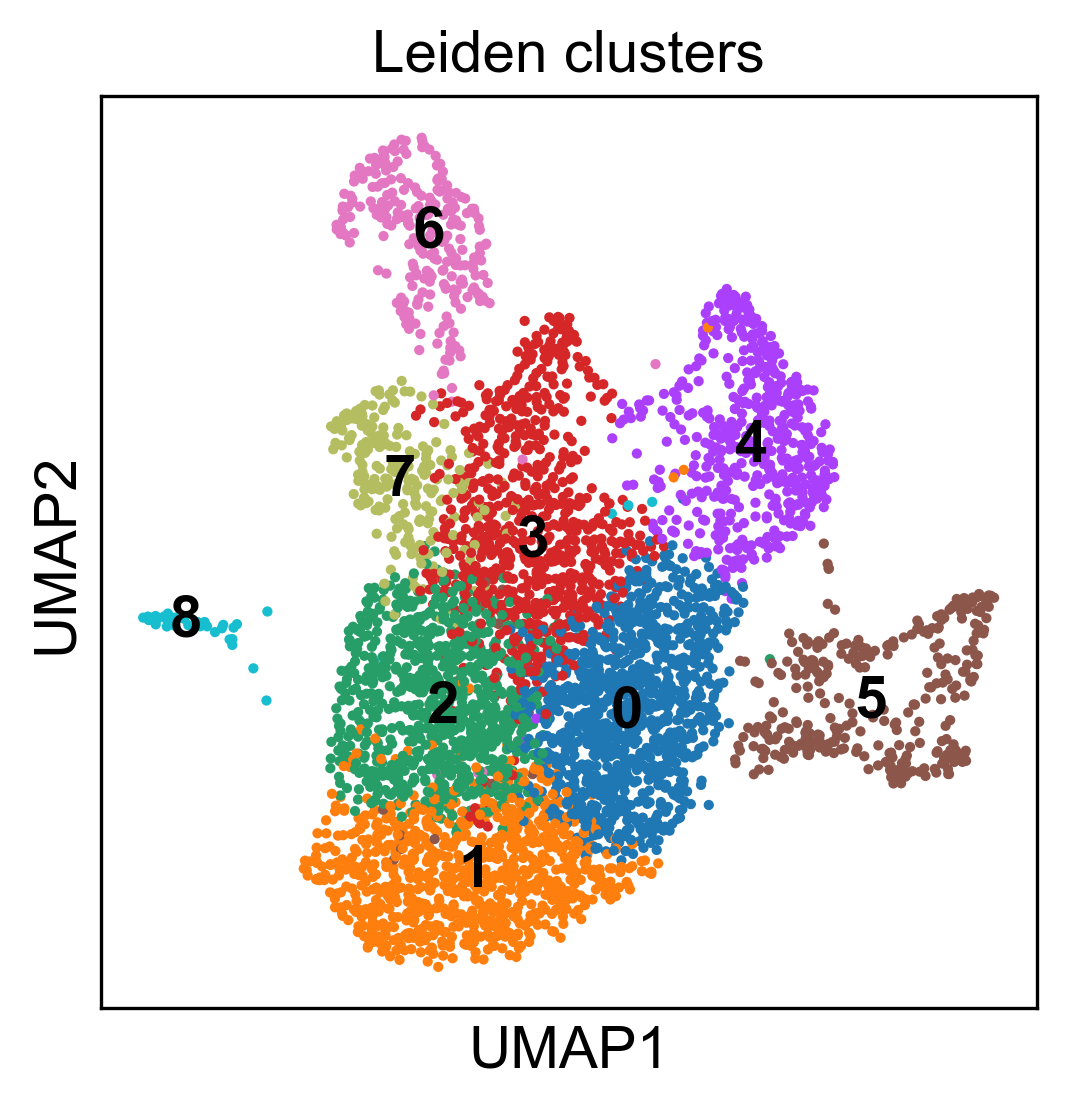

In [15]:
# Build neighbour graph using top 20 PCs
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)
print("Neighbour graph built")

# Run UMAP
sc.tl.umap(adata)
print("UMAP Complete")

# Run Leiden clustering
sc.tl.leiden(adata, resolution=0.5)
print(f"Leiden clustering complete")
print(f"Number of clusters found: {adata.obs['leiden'].nunique()}")
print(f"Cluster sizes:\n{adata.obs['leiden'].value_counts().sort_index()}")

# Plot UMAP coloured by cluster
sc.pl.umap(
    adata,
    color=['leiden'],
    legend_loc='on data',
    title='Leiden clusters',
    save='_clusters.png'
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:25)


C:\Users\Dell\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
C:\Users\Dell\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
C:\Users\Dell\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
C:\Users\Dell\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
C:\Users\Dell\anaconda3\envs\scrna\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\Dell\anaconda3\envs\scrna\lib\site-packages\s

Marker genes calculated


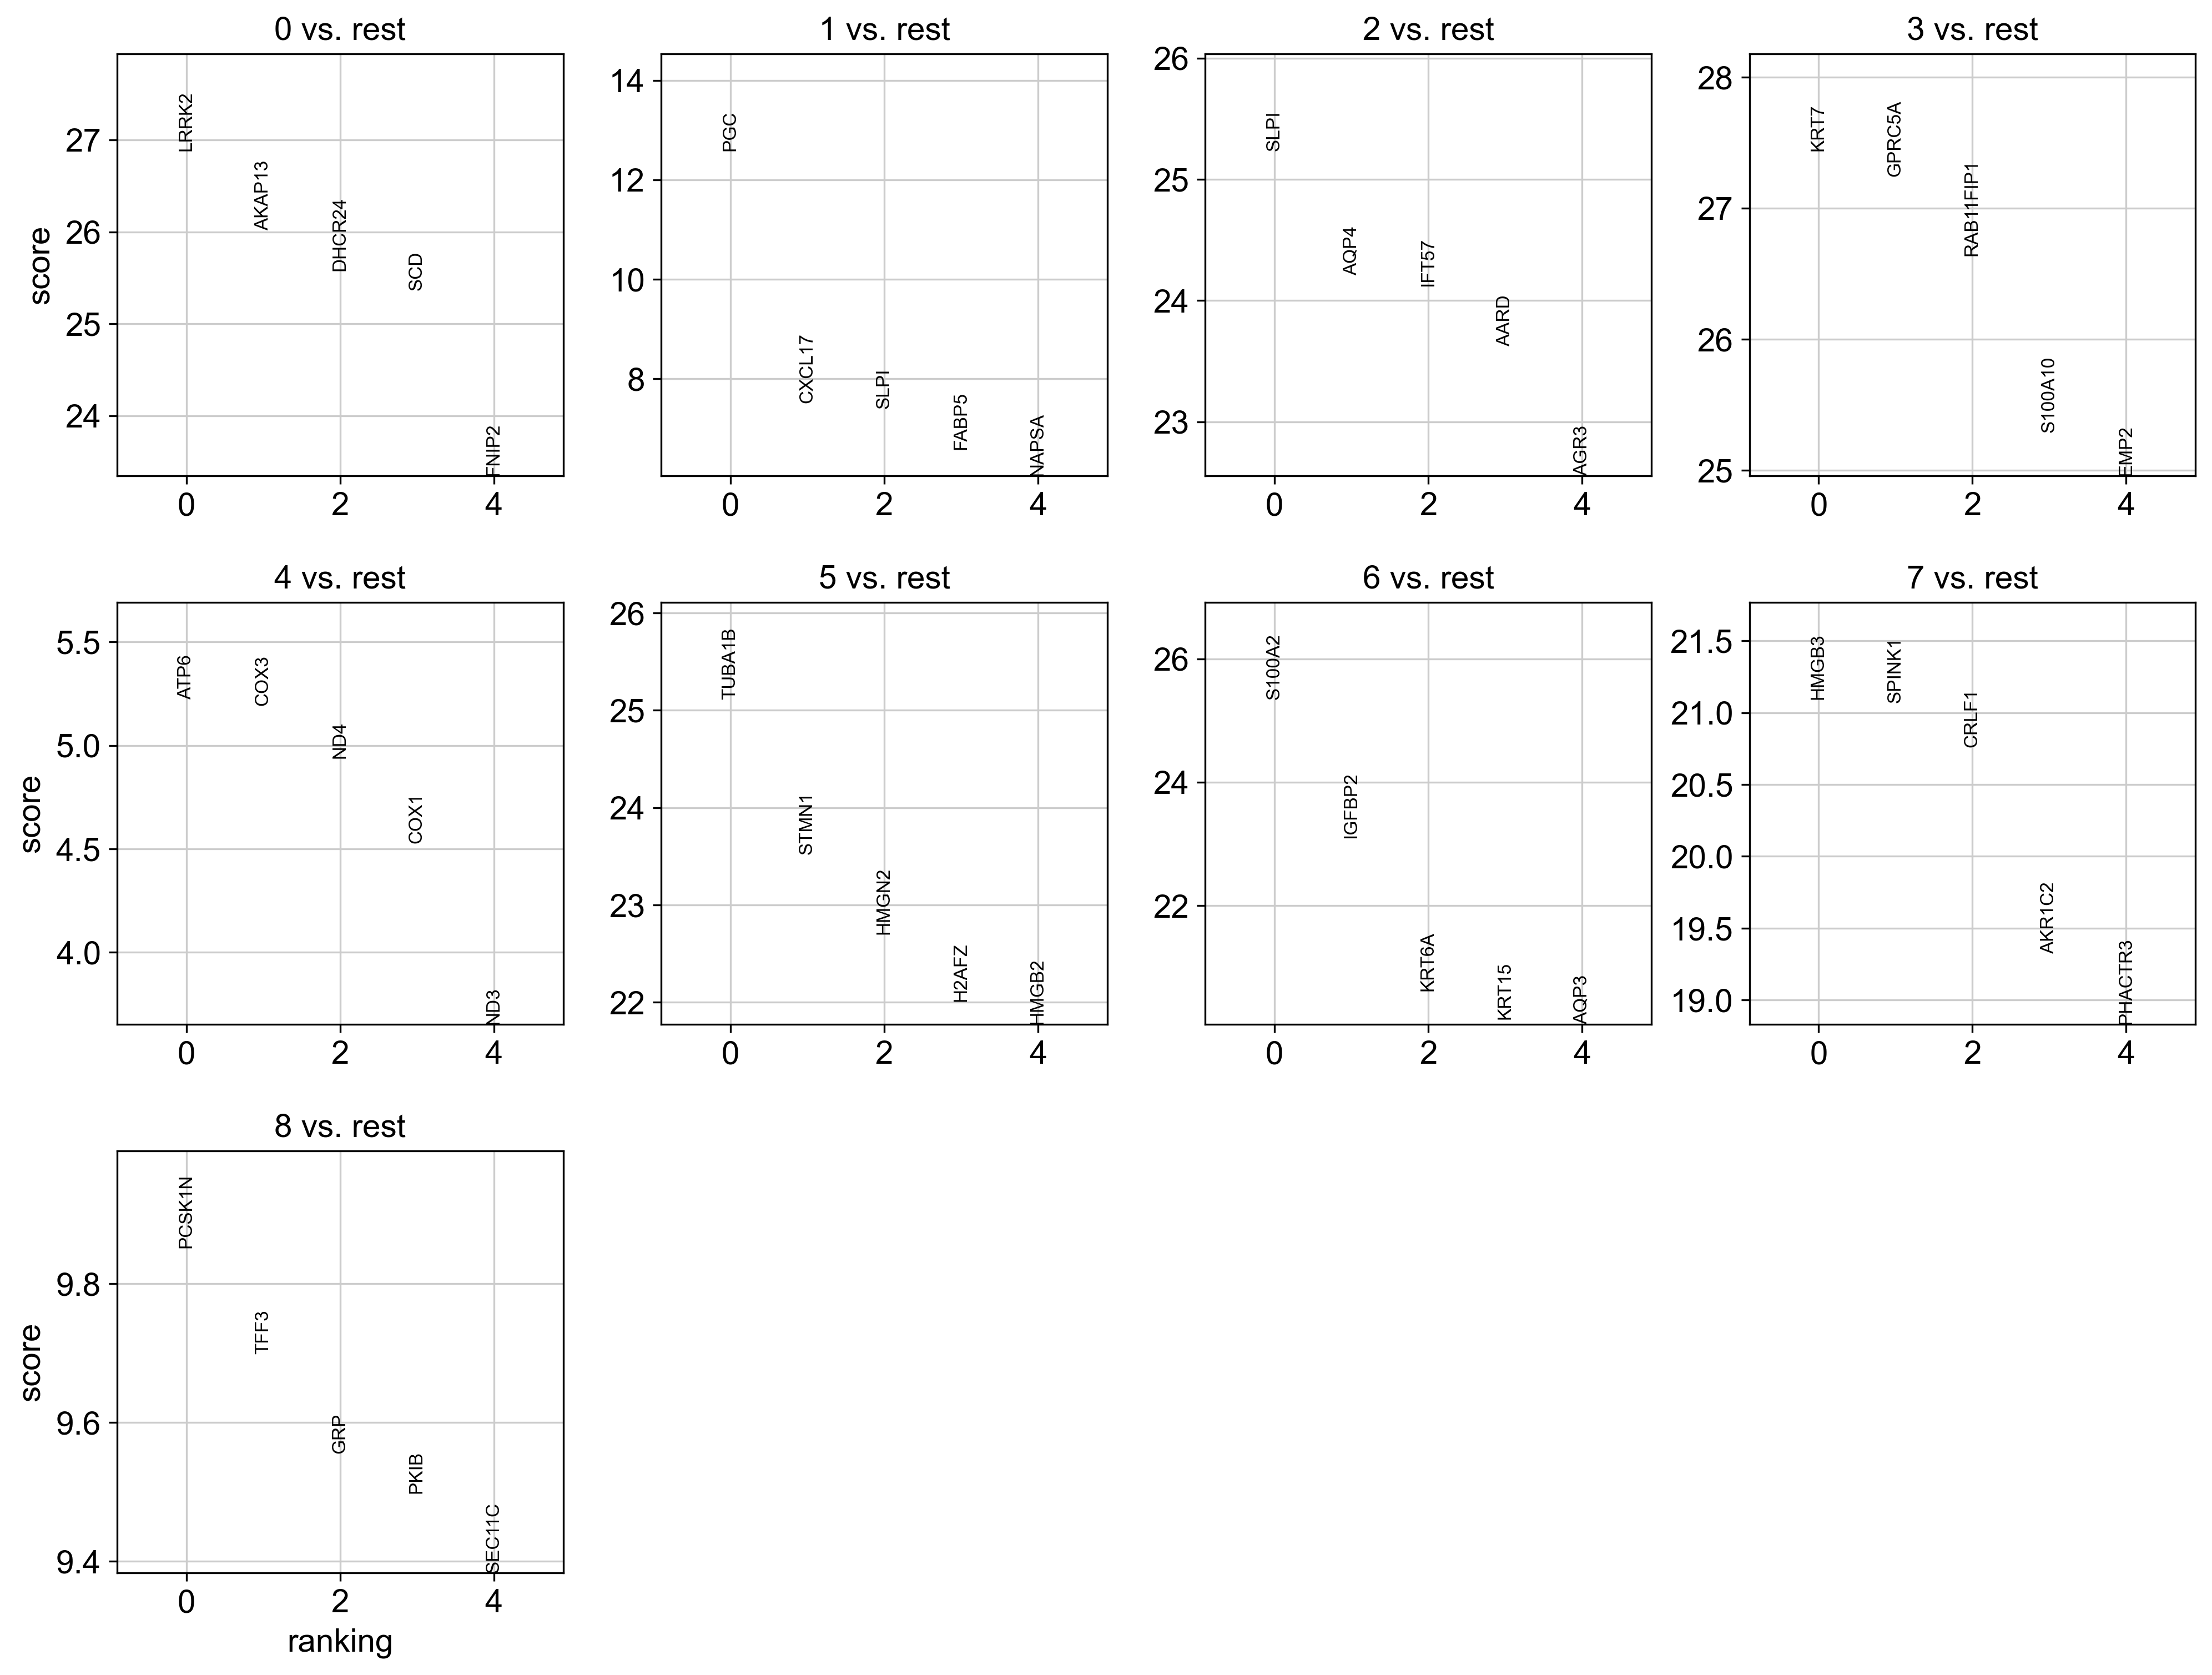


Top 3 marker genes per cluster:
  Cluster 0: ['LRRK2', 'AKAP13', 'DHCR24']
  Cluster 1: ['PGC', 'CXCL17', 'SLPI']
  Cluster 2: ['SLPI', 'AQP4', 'IFT57']
  Cluster 3: ['KRT7', 'GPRC5A', 'RAB11FIP1']
  Cluster 4: ['ATP6', 'COX3', 'ND4']
  Cluster 5: ['TUBA1B', 'STMN1', 'HMGN2']
  Cluster 6: ['S100A2', 'IGFBP2', 'KRT6A']
  Cluster 7: ['HMGB3', 'SPINK1', 'CRLF1']
  Cluster 8: ['PCSK1N', 'TFF3', 'GRP']


In [16]:
# Find marker genes for each cluster
sc.tl.rank_genes_groups(
    adata,
    'leiden',
    method='wilcoxon',
    key_added='rank_genes_groups'
)
print("Marker genes calculated")

# Show top 5 marker genes per cluster
sc.pl.rank_genes_groups(
    adata,
    n_genes=5,
    sharey=False,
    save='_markers.png'
)

# Print top 3 markers per cluster neatly
print("\nTop 3 marker genes per cluster:")
for i in range(9):
    genes = sc.get.rank_genes_groups_df(adata, group=str(i))['names'][:3].tolist()
    print(f"  Cluster {i}: {genes}")

In [17]:
# Cluster 5 → Proliferating (STMN1, TUBA1B are classic dividing cell markers)
# Cluster 8 → PNEC (GRP, PCSK1N are classic PNEC markers)
# Cluster 6 → likely Basal (S100A2, KRT6A)
# Clusters 0-3 → likely ATII/ATI subtypes

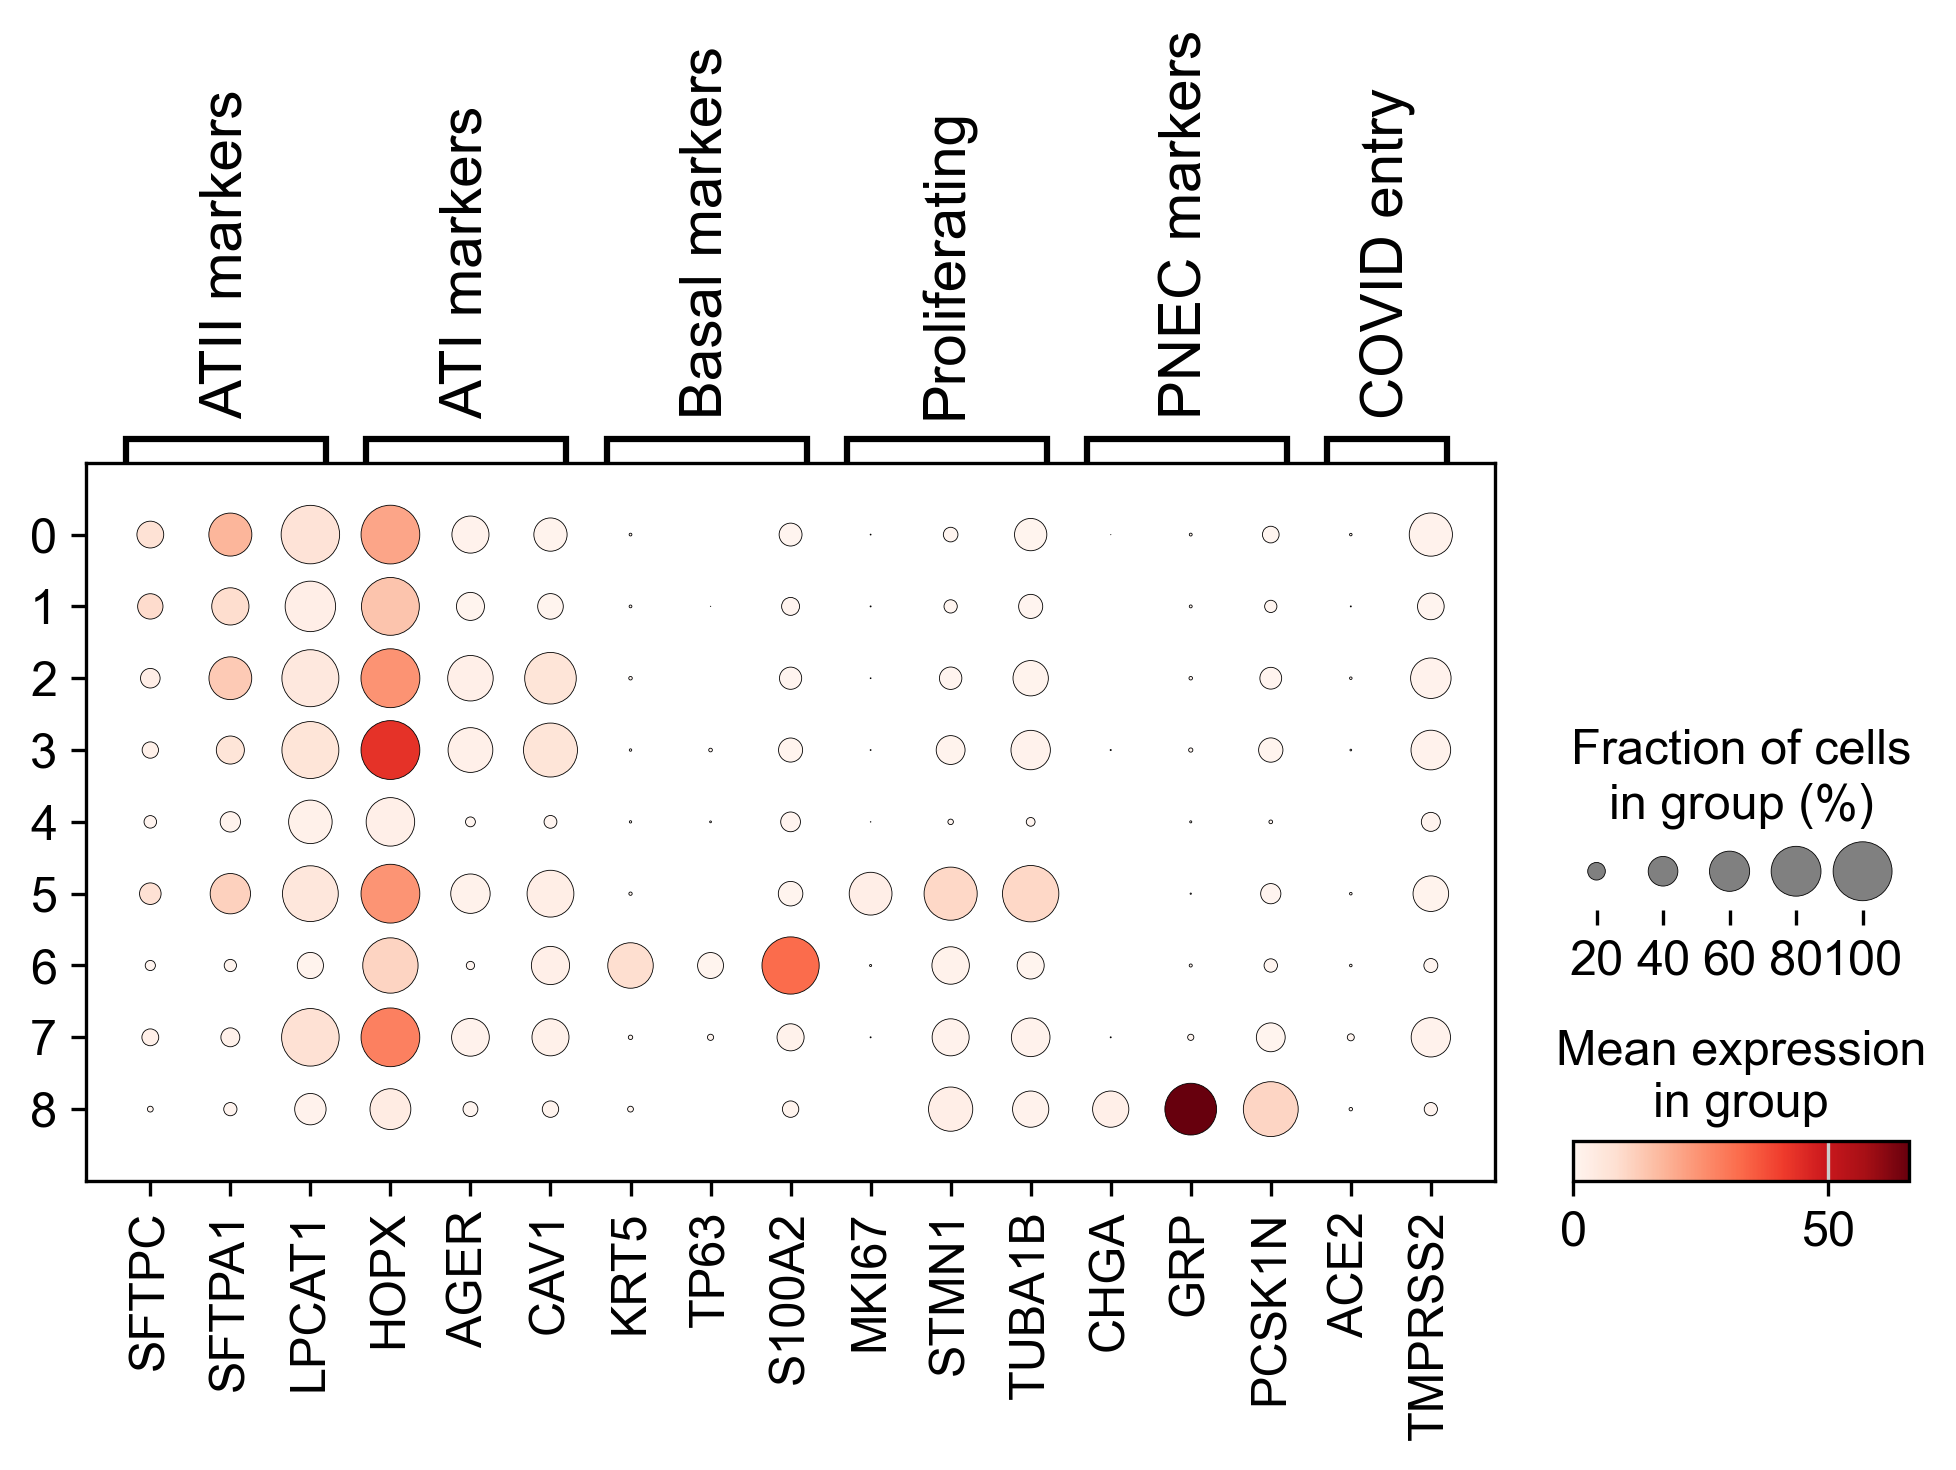

Checking key genes present in dataset:
  SFTPC: YES
  SFTPA1: YES
  HOPX: NO
  AGER: YES
  KRT5: YES
  TP63: YES
  MKI67: YES
  STMN1: YES
  CHGA: YES
  GRP: YES
  PCSK1N: YES
  S100A2: YES
  ACE2: YES
  TMPRSS2: NO


In [18]:
# Check key Lamers paper markers across all clusters
marker_genes_dict = {
    'ATII markers': ['SFTPC', 'SFTPA1', 'LPCAT1'],
    'ATI markers': ['HOPX', 'AGER', 'CAV1'],
    'Basal markers': ['KRT5', 'TP63', 'S100A2'],
    'Proliferating': ['MKI67', 'STMN1', 'TUBA1B'],
    'PNEC markers': ['CHGA', 'GRP', 'PCSK1N'],
    'COVID entry': ['ACE2', 'TMPRSS2'],
}

sc.pl.dotplot(
    adata,
    marker_genes_dict,
    groupby='leiden',
    save='_dotplot_markers.png'
)

# Also check which of these genes exist in our dataset
print("Checking key genes present in dataset:")
all_markers = ['SFTPC','SFTPA1','HOPX','AGER','KRT5','TP63','MKI67',
               'STMN1','CHGA','GRP','PCSK1N','S100A2','ACE2','TMPRSS2']
for g in all_markers:
    present = g in adata.var_names
    print(f"  {g}: {'YES' if present else 'NO'}")

In [19]:
# Excellent! ACE2 is present 
# that's the most important one. 
# HOPX and TMPRSS2 are absent but we have good alternatives.

In [20]:
# Check expression levels of key genes per cluster
import pandas as pd

genes_to_check = ['SFTPC', 'SFTPA1', 'AGER', 'KRT5', 'TP63', 
                  'MKI67', 'STMN1', 'CHGA', 'GRP', 'PCSK1N', 
                  'S100A2', 'ACE2']

# Calculate mean expression per cluster for each gene
mean_expr = pd.DataFrame(index=genes_to_check, columns=sorted(adata.obs['leiden'].unique()))

for gene in genes_to_check:
    if gene in adata.var_names:
        for cluster in sorted(adata.obs['leiden'].unique()):
            cells = adata.obs['leiden'] == cluster
            expr = adata[cells, gene].X.toarray().flatten()
            mean_expr.loc[gene, cluster] = expr.mean().round(3)

print("Mean expression per cluster:")
print(mean_expr.to_string())


# This will give us a clear number table showing which gene is highest in which cluster

Mean expression per cluster:
            0      1      2      3      4      5      6      7      8
SFTPC   0.202  0.335 -0.111 -0.216 -0.188 -0.015 -0.327 -0.201 -0.431
SFTPA1   0.37  0.217  0.238 -0.331 -0.423  0.095 -0.695 -0.619 -0.682
AGER    -0.03 -0.118   0.46   0.35 -0.617  0.064  -0.74 -0.039 -0.657
KRT5   -0.191 -0.155 -0.179  -0.19 -0.166 -0.175  3.171 -0.151 -0.127
TP63   -0.143 -0.135 -0.143 -0.042 -0.054 -0.143   1.83  0.043 -0.143
MKI67  -0.194 -0.188 -0.196 -0.193 -0.192  2.721 -0.159 -0.188 -0.201
STMN1  -0.327 -0.273 -0.216  0.055 -0.414  2.215  0.519  0.234  0.967
CHGA   -0.066 -0.069 -0.069 -0.041 -0.069 -0.069 -0.069 -0.051  4.906
GRP    -0.088 -0.053  -0.08 -0.062 -0.062 -0.119 -0.093 -0.041  7.131
PCSK1N -0.104 -0.097  0.057  0.158 -0.336 -0.055 -0.142   0.25   4.53
S100A2 -0.213 -0.196 -0.239  -0.17  0.026 -0.185  3.163 -0.125  -0.21
ACE2     0.02 -0.063  0.016 -0.032 -0.102 -0.021  0.002  0.276  0.021


In [21]:
# Cluster 8 = PNEC — the numbers are unmistakable (GRP = 7.1!)
# Cluster 6 = Basal — KRT5 and S100A2 both very high
# Cluster 5 = Proliferating — MKI67 dominant
# Cluster 7 has the highest ACE2 (0.276) — this is already interesting for your COVID story
# Clusters 0 and 1 = ATII, Clusters 2 and 3 = ATI

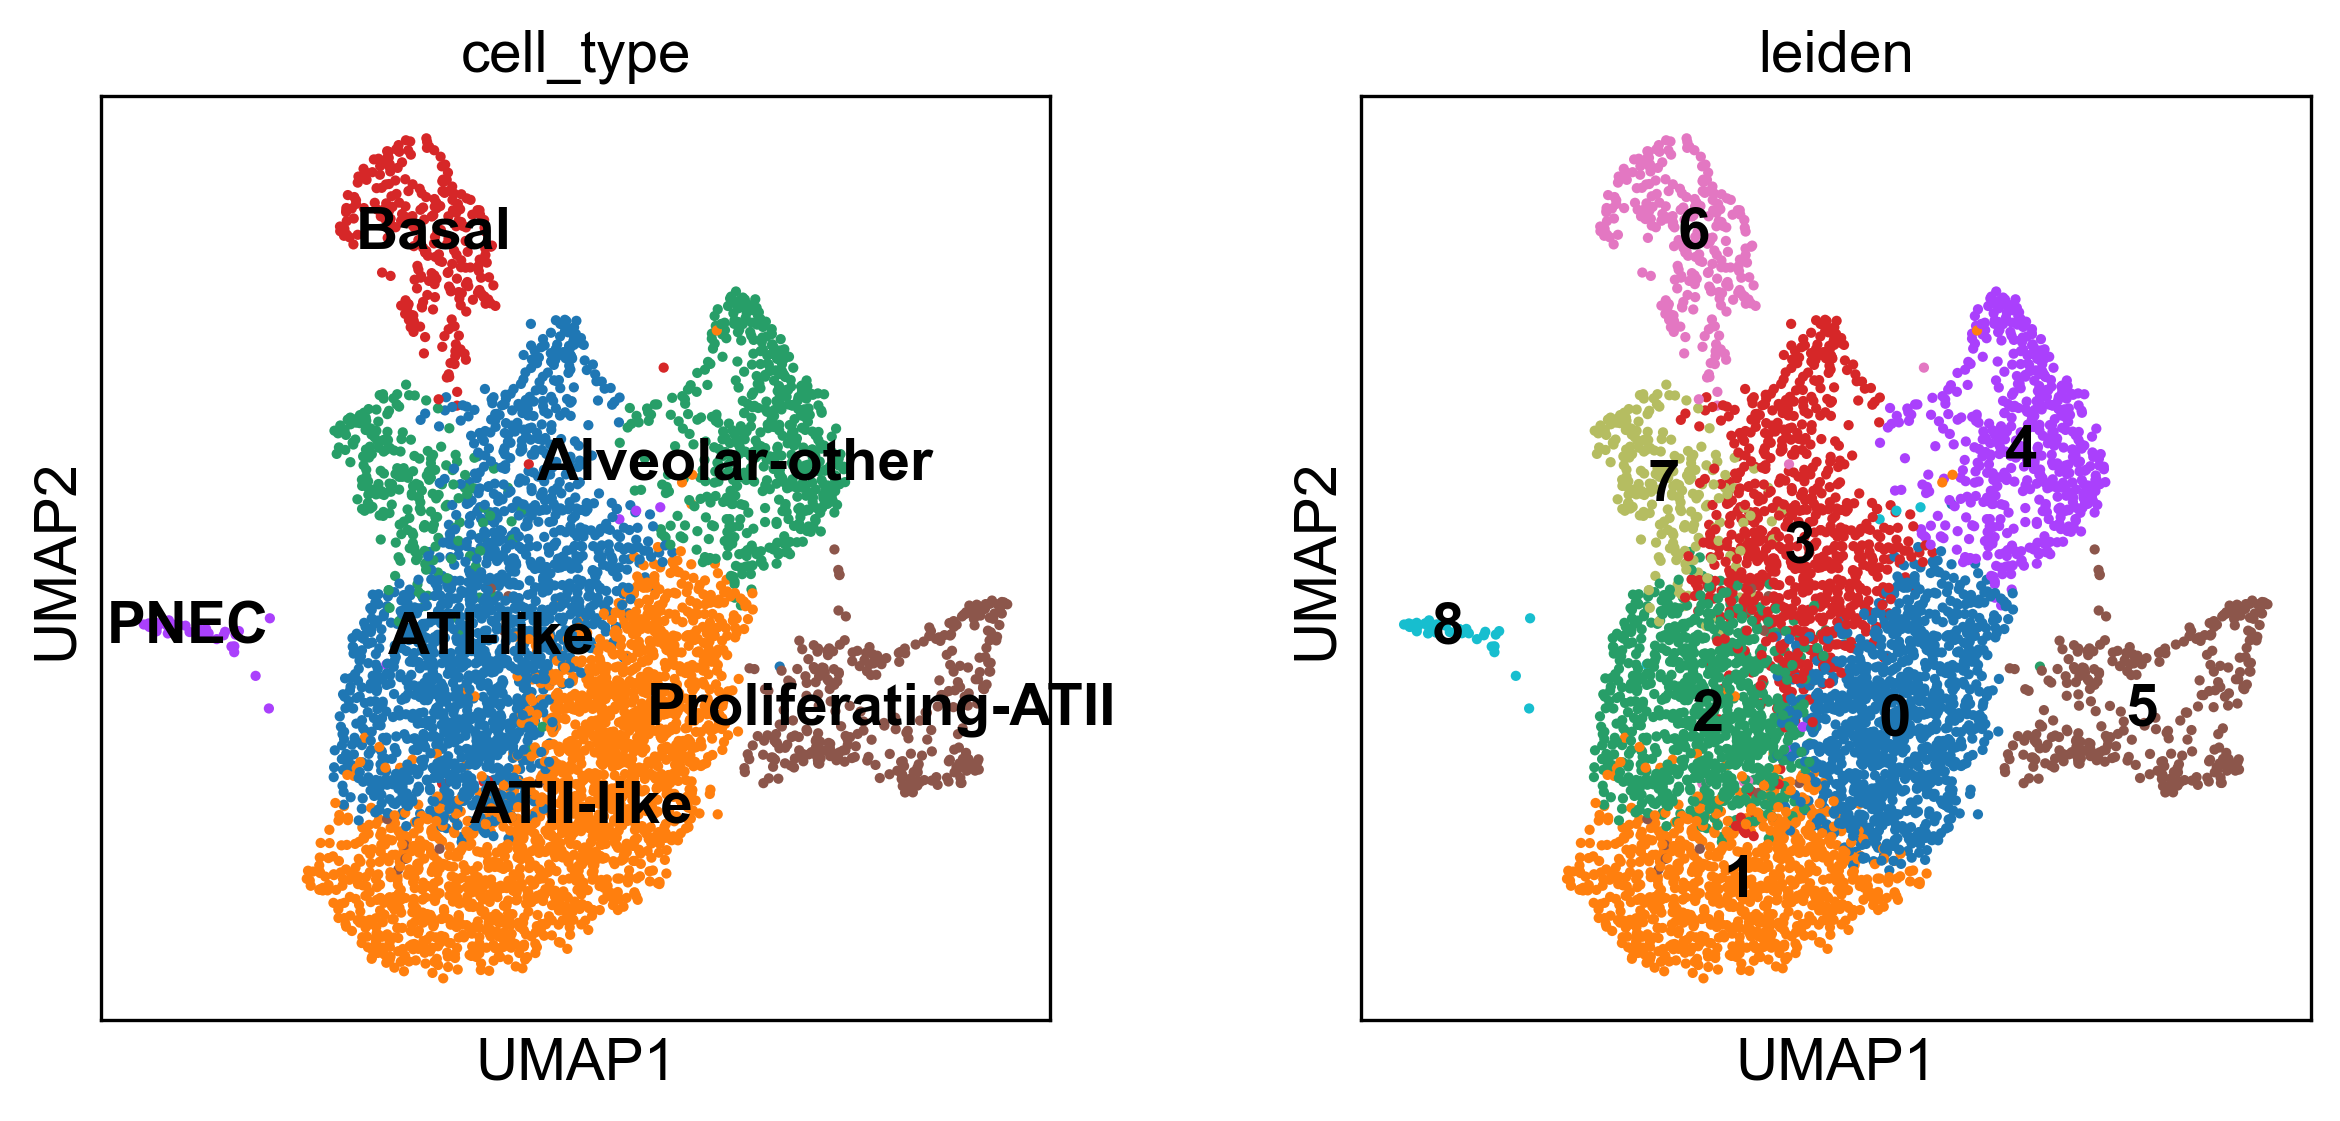

Cell type counts:
cell_type
ATII-like             1956
ATI-like              1635
Alveolar-other         743
Proliferating-ATII     325
Basal                  260
PNEC                    44
Name: count, dtype: int64

Saved to data/adata_annotated.h5ad


In [22]:
# Assign cell type labels based on expression table
cluster_to_type = {
    '0': 'ATII-like',          # SFTPC high, SFTPA1 high
    '1': 'ATII-like',          # SFTPC highest, SFTPA1 high
    '2': 'ATI-like',           # AGER highest (0.46)
    '3': 'ATI-like',           # AGER high (0.35), PCSK1N some
    '4': 'Alveolar-other',     # ATP6/COX3/ND4 markers = mitochondrial-rich cells
    '5': 'Proliferating-ATII', # MKI67 very high (2.72), STMN1 high
    '6': 'Basal',              # KRT5 very high (3.17), TP63 high (1.83), S100A2 high
    '7': 'Alveolar-other',     # ACE2 highest of all clusters (0.276)!
    '8': 'PNEC',               # CHGA (4.9), GRP (7.1), PCSK1N (4.5) — unmistakable
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_type)

# Plot UMAP with cell type labels
sc.pl.umap(
    adata,
    color=['cell_type', 'leiden'],
    legend_loc='on data',
    save='_celltypes.png'
)

# Print summary
print("Cell type counts:")
print(adata.obs['cell_type'].value_counts())

# Save annotated object
adata.write('../data/adata_annotated.h5ad')
print("\nSaved to data/adata_annotated.h5ad")

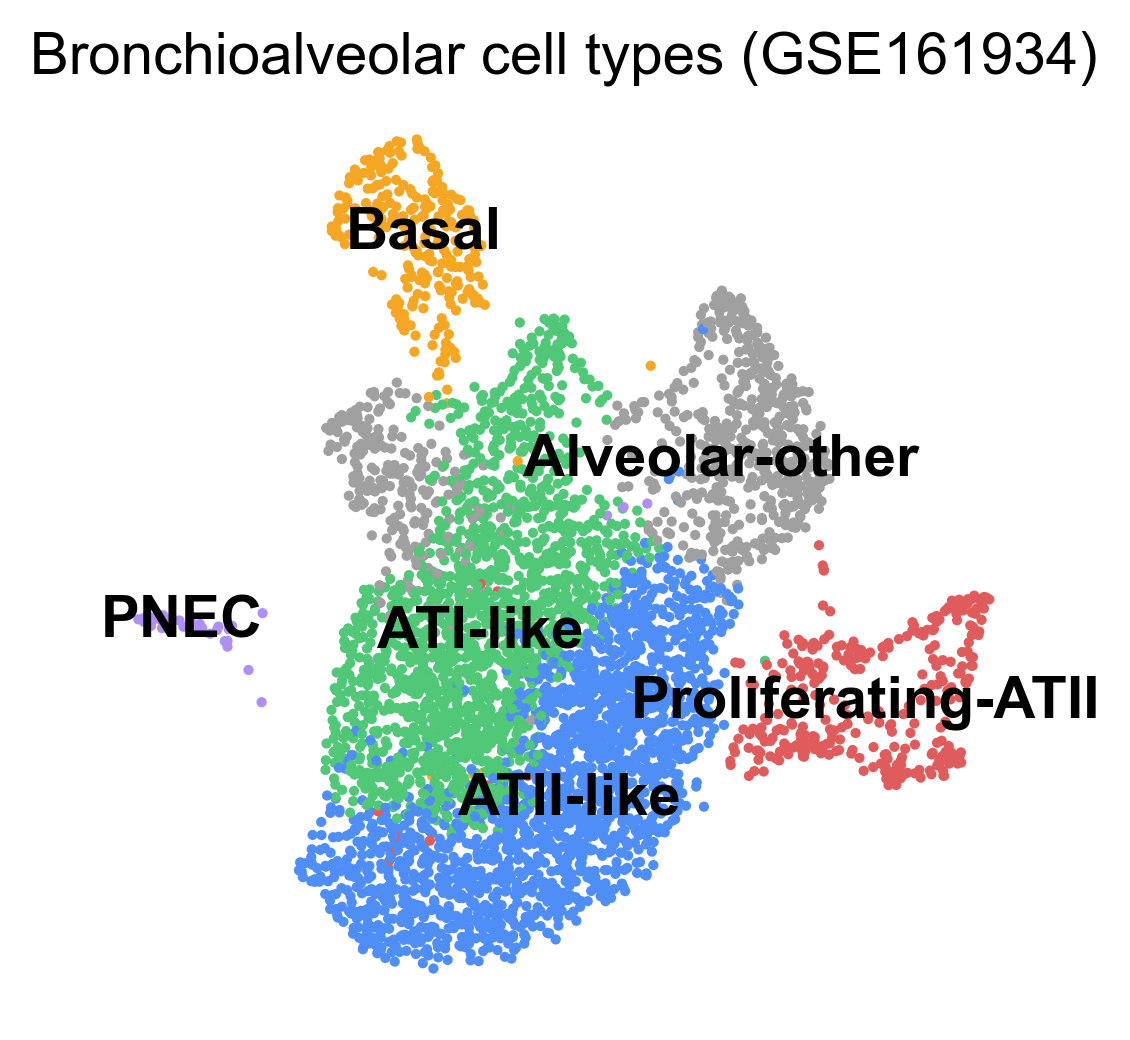


Summary so far:
  Cells analysed: 4963
  Cell types identified: 6
  Figures saved to: ../figures/
  Data saved to: ../data/adata_annotated.h5ad


In [23]:
# Final UMAP with clean colours matching Lamers paper style
import matplotlib.pyplot as plt

cell_type_colors = {
    'ATII-like': '#4f8ef7',
    'ATI-like': '#50c878',
    'Proliferating-ATII': '#e05c5c',
    'Basal': '#f5a623',
    'Alveolar-other': '#a0a0a0',
    'PNEC': '#b08ff5',
}

sc.pl.umap(
    adata,
    color='cell_type',
    palette=cell_type_colors,
    legend_loc='on data',
    title='Bronchioalveolar cell types (GSE161934)',
    frameon=False,
    save='_final_celltypes.png'
)

print("\nSummary so far:")
print(f"  Cells analysed: {adata.n_obs}")
print(f"  Cell types identified: {adata.obs['cell_type'].nunique()}")
print(f"  Figures saved to: ../figures/")
print(f"  Data saved to: ../data/adata_annotated.h5ad")
